# E11 - EfficientNet-B3, weighted cross-entropy, 300px

| | |
|---|---|
| Architecture | `efficientnet_b3` |
| Imbalance strategy | `weighted_ce` |
| Input resolution | 300x300 |
| Group | EfficientNet-B3 ablation |
| Optimiser | Adam, lr 1e-3, betas (0.9, 0.999) |
| Batch size | 32 |
| Schedule | max 50 epochs, early stopping on val loss, patience 10 |
| Seed | 42 |

B3 at 300 with weighted CE, paired against E8.

Training is checkpointed after every epoch. If the pod drops, re-run the training cell
and it picks up from the last completed epoch rather than starting over.

In [4]:
import json, sys, time
from pathlib import Path

# Works whether the kernel starts in notebooks/ or at the repo root.
ROOT = Path.cwd()
while not (ROOT / "src" / "ham10000").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

# /workspace is a MooseFS network volume and per-file reads over FUSE were the
# bottleneck, not the GPU: 45 img/s there against 241 img/s from RAM. Notebook 01
# stages a copy into /dev/shm. Fall back to the on-disk copy if it is missing,
# since tmpfs does not survive a pod restart.
FAST = Path("/dev/shm/ham_data")
DATA = FAST if (FAST / "HAM10000_metadata.csv").exists() else ROOT / "data"
RUNS = ROOT / "runs"
print("repo:   ", ROOT)
print("data:   ", DATA, "(RAM)" if str(DATA).startswith("/dev/shm") else "(disk, slower)")

repo:    /workspace/ham10000-cnn-comparison
data:    /dev/shm/ham_data (RAM)


In [5]:
from ham10000.constants import EXPERIMENTS, experiment_label
from ham10000.train import TrainConfig, train_experiment

EXP = "E11"
print(experiment_label(EXP))
print(EXPERIMENTS[EXP])

E11 EfficientNet-B3 @300 / Weighted CE
{'architecture': 'efficientnet_b3', 'strategy': 'weighted_ce', 'image_size': 300}


## Preflight

Confirms the GPU, the data and the shared split before anything expensive starts.

In [6]:
import torch
from ham10000.split import load_or_create_split, split_hash

assert torch.cuda.is_available(), "No GPU. Stop here."
print("gpu :", torch.cuda.get_device_name(0))

assert (DATA / "HAM10000_metadata.csv").exists(), "Run notebook 01 first."
df, lesion_splits = load_or_create_split(DATA / "HAM10000_metadata.csv",
                                         RUNS / "splits" / "seed42_lesion_stratified.json")
print("split hash :", split_hash(lesion_splits))
print(df.split.value_counts().to_dict())

gpu : NVIDIA RTX A4500
split hash : f35ac1de18678182
{'train': 8012, 'test': 1024, 'val': 979}


## Train

Expect this to take a while. At 300px each epoch handles about 1.8x the pixels of the 224px runs, so budget accordingly.

The cell is safe to re-run: if `test_metrics.json` already exists it returns the cached
result instead of retraining. Pass `force_rerun=True` if you genuinely want it redone.

In [7]:
config = TrainConfig(
    experiment_id=EXP,
    data_root=str(DATA),
    output_dir=str(RUNS / EXP),
    seed=42,
    batch_size=32,
    lr=1e-3,
    max_epochs=50,
    patience=10,
    num_workers=16,
)

start = time.time()
result = train_experiment(config)
print(f"\nwall clock: {(time.time() - start) / 60:.1f} min")

vram: 20.8 GB free, ~10.2 GB needed
Epoch 1/50 | train loss 1.3163 acc 0.5580 | val loss 0.7617 macro-F1 0.5261
Epoch 2/50 | train loss 1.0490 acc 0.6206 | val loss 1.6416 macro-F1 0.4303
Epoch 3/50 | train loss 0.9101 acc 0.6655 | val loss 0.9463 macro-F1 0.5435
Epoch 4/50 | train loss 0.7130 acc 0.7157 | val loss 0.6714 macro-F1 0.6407
Epoch 5/50 | train loss 0.6956 acc 0.7099 | val loss 0.6723 macro-F1 0.6652
Epoch 6/50 | train loss 0.5969 acc 0.7541 | val loss 1.6635 macro-F1 0.5320
Epoch 7/50 | train loss 0.6124 acc 0.7445 | val loss 0.6960 macro-F1 0.6629
Epoch 8/50 | train loss 0.4748 acc 0.7755 | val loss 0.6216 macro-F1 0.6926
Epoch 9/50 | train loss 0.5411 acc 0.7676 | val loss 0.8089 macro-F1 0.5857
Epoch 10/50 | train loss 0.4963 acc 0.7625 | val loss 0.6906 macro-F1 0.6701
Epoch 11/50 | train loss 0.4245 acc 0.7891 | val loss 0.5884 macro-F1 0.6619
Epoch 12/50 | train loss 0.4390 acc 0.7944 | val loss 0.5637 macro-F1 0.6939
Epoch 13/50 | train loss 0.3472 acc 0.8143 | val 

## Results

In [8]:
import pandas as pd
from ham10000.constants import CLASS_NAMES

m = result["test_metrics"]
report = m["classification_report"]

print(f"accuracy          {m['accuracy']:.4f}")
print(f"balanced accuracy {m['balanced_accuracy']:.4f}")
print(f"macro F1          {m['macro_f1']:.4f}")
print(f"macro AUC (OvR)   {m['macro_auc_ovr']:.4f}\n")

table = pd.DataFrame([{
    "class": c,
    "precision": report[str(i)]["precision"],
    "recall": report[str(i)]["recall"],
    "f1": report[str(i)]["f1-score"],
    "support": int(report[str(i)]["support"]),
} for i, c in enumerate(CLASS_NAMES)]).set_index("class").round(4)
print(table)

rq2 = (report[str(CLASS_NAMES.index("mel"))]["recall"]
       + report[str(CLASS_NAMES.index("bcc"))]["recall"]) / 2
print(f"\nRQ2 criterion, mean(recall MEL, recall BCC) = {rq2:.4f}")

accuracy          0.8047
balanced accuracy 0.7699
macro F1          0.7376
macro AUC (OvR)   0.9642

       precision  recall      f1  support
class                                    
akiec     0.5517  0.9697  0.7033       33
bcc       0.7213  0.8302  0.7719       53
bkl       0.6771  0.6190  0.6468      105
df        0.8889  0.6154  0.7273       13
mel       0.4659  0.7130  0.5636      115
nv        0.9509  0.8420  0.8932      690
vasc      0.9231  0.8000  0.8571       15

RQ2 criterion, mean(recall MEL, recall BCC) = 0.7716


### Training curve

Val loss is what early stopping watches. Val macro F1 is what actually matters, and the
two do not always move together.

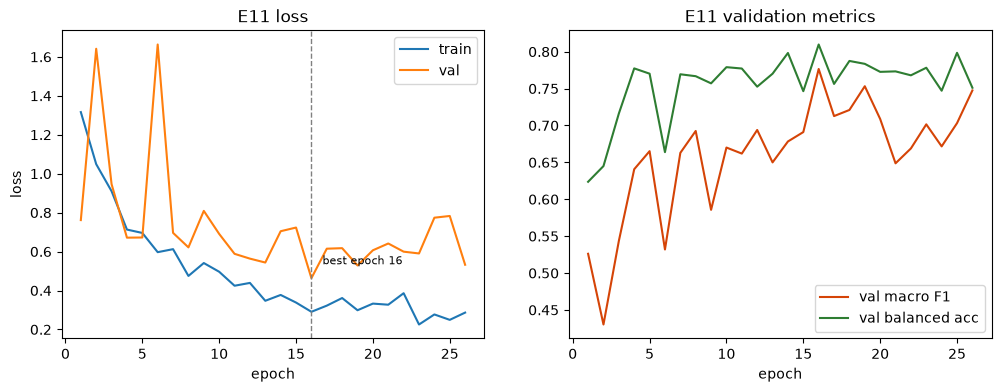

stopped after 26 epochs, best val loss 0.4634 at epoch 16


In [9]:
import matplotlib.pyplot as plt

h = pd.read_csv(RUNS / EXP / "history.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h.epoch, h.train_loss, label="train")
axes[0].plot(h.epoch, h.val_loss, label="val")
best = h.loc[h.val_loss.idxmin()]
axes[0].axvline(best.epoch, ls="--", c="grey", lw=1)
axes[0].annotate(f"best epoch {int(best.epoch)}", (best.epoch, best.val_loss),
                 textcoords="offset points", xytext=(8, 10), fontsize=8)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[0].set_title(f"{EXP} loss")

axes[1].plot(h.epoch, h.val_macro_f1, color="#D54407", label="val macro F1")
axes[1].plot(h.epoch, h.val_balanced_accuracy, color="#2E7D32", label="val balanced acc")
axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].set_title(f"{EXP} validation metrics")
plt.show()

print(f"stopped after {len(h)} epochs, best val loss {h.val_loss.min():.4f} at epoch {int(best.epoch)}")

### Confusion matrix

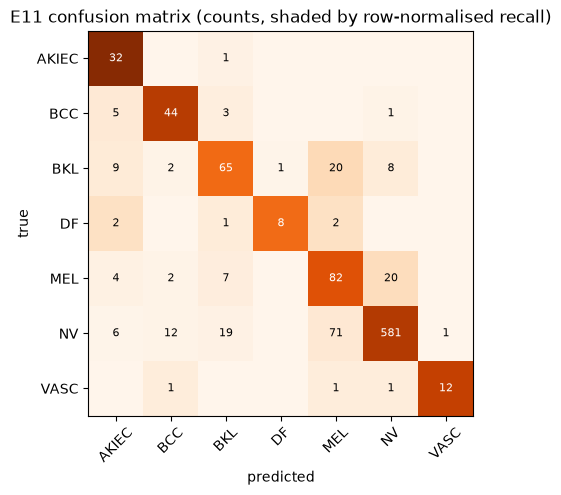

melanomas called NV: 20 of 115
This is the clinically costly error: a cancer sent home as a benign mole.


In [10]:
import numpy as np

cm = np.array(m["confusion_matrix"], dtype=float)
norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(norm, cmap="Oranges", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        if cm[i, j]:
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if norm[i, j] > 0.55 else "black")
ax.set_xticks(range(7), [c.upper() for c in CLASS_NAMES], rotation=45)
ax.set_yticks(range(7), [c.upper() for c in CLASS_NAMES])
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"{EXP} confusion matrix (counts, shaded by row-normalised recall)")
ax.grid(False)
plt.show()

mel, nv = CLASS_NAMES.index("mel"), CLASS_NAMES.index("nv")
print(f"melanomas called NV: {int(cm[mel, nv])} of {int(cm[mel].sum())}")
print("This is the clinically costly error: a cancer sent home as a benign mole.")

### Files written

These five are what the analysis notebooks read. Nothing later re-derives them.

In [11]:
for f in sorted((RUNS / EXP).iterdir()):
    print(f"{f.name:<24} {f.stat().st_size/1e6:>8.2f} MB")

checkpoint_best.pt         129.34 MB
checkpoint_last.pt         129.34 MB
config.json                  0.00 MB
history.csv                  0.00 MB
test_metrics.json            0.00 MB
test_predictions.csv         0.02 MB
